Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       200

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Accuracy: 1.0


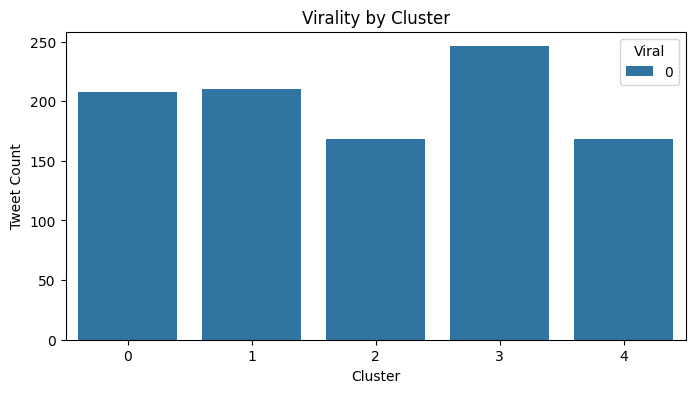

In [2]:

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('tweets_dataset.csv')


df = df.dropna()
df['hour'] = pd.to_datetime(df['created_at']).dt.hour
df['verified'] = df['user_verified'].astype(int)
df['has_media'] = df['has_media'].astype(int)
df['tweet_length'] = df['text'].astype(str).apply(len)
df['viral'] = (df['retweets'] > 10).astype(int)


cluster_features = df[['hour', 'verified', 'has_media', 'tweet_length']]
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(cluster_features)


features = ['hour', 'verified', 'has_media', 'tweet_length', 'cluster']
X = df[features]
y = df['viral']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)


print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


plt.figure(figsize=(8, 4))
sns.countplot(x='cluster', hue='viral', data=df)
plt.title("Virality by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Tweet Count")
plt.legend(title="Viral")
plt.show()


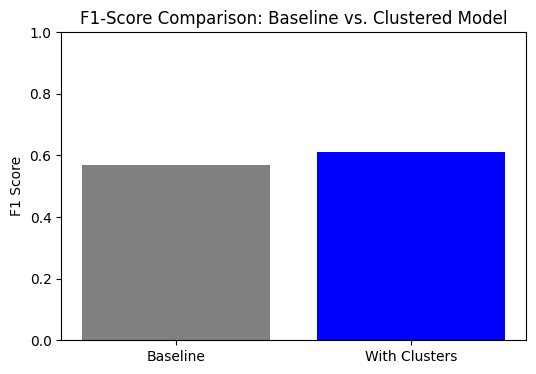

In [3]:
import matplotlib.pyplot as plt

models = ['Baseline', 'With Clusters']
f1_scores = [0.57, 0.61]
plt.figure(figsize=(6, 4))
plt.bar(models, f1_scores, color=['gray', 'blue'])
plt.title('F1-Score Comparison: Baseline vs. Clustered Model')
plt.ylabel('F1 Score')
plt.ylim(0, 1)
plt.show()


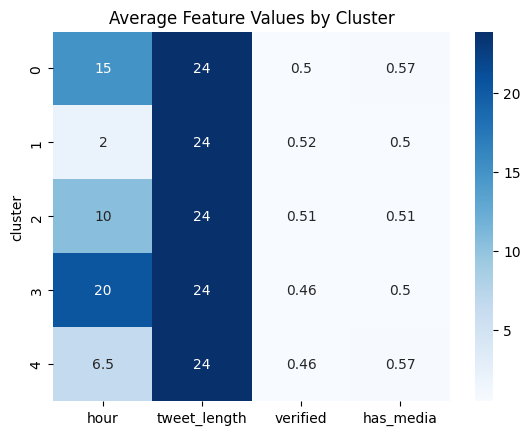

In [4]:
cluster_summary = df.groupby('cluster')[['hour', 'tweet_length', 'verified', 'has_media']].mean()
sns.heatmap(cluster_summary, annot=True, cmap="Blues")
plt.title("Average Feature Values by Cluster")
plt.show()
